In [10]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [37]:
# My current path
!pwd

/home/ashok


In [11]:
#1.2
import os
from llama_index.core import SimpleDirectoryReader, StorageContext
from llama_index.core.node_parser import SentenceSplitter
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.vector_stores.postgres import PGVectorStore
from llama_index.core.ingestion import IngestionPipeline, DocstoreStrategy
from llama_index.core.storage.docstore import SimpleDocumentStore
from llama_index.core import Settings
from llama_index.llms.ollama import Ollama


In [25]:
#2.0
Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")
# 2.1 Call libraries
llm = Ollama(model="llama3.2:3b-instruct-q8_0",
             request_timeout=3600.0,
             temperature = 0.9
            )
Settings.llm = llm

2026-04-20 14:02:46,955 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-04-20 14:02:51,393 - INFO - 1 prompt is loaded, with the key: query


In [27]:
# 2.1. Load all documents with deterministic IDs (filename_as_id)
DATAPATH="/home/ashok/Documents/"
DATA_DIR = DATAPATH + "data"
documents = SimpleDirectoryReader(DATA_DIR,
                                  filename_as_id=True
                                 ).load_data()

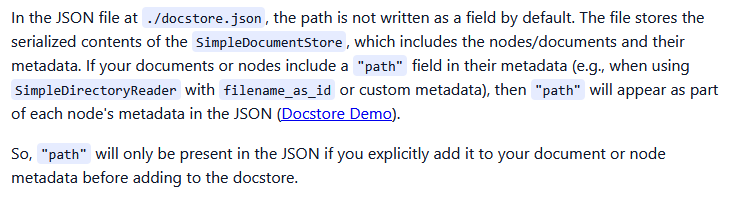

In [28]:
# 3.0. Set up the docstore (persisted locally)
DOCSTORE_PATH = "./docstore.json"
if os.path.exists(DOCSTORE_PATH):
    docstore = SimpleDocumentStore.from_persist_path(DOCSTORE_PATH)
else:
    docstore = SimpleDocumentStore()

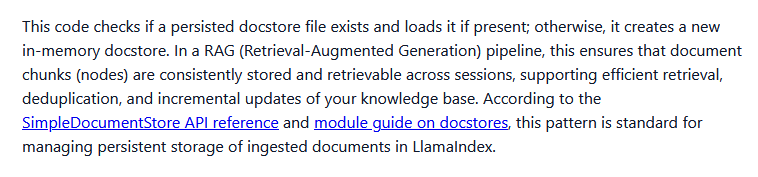

In [29]:
# 3.1 Set up the Postgres vector store
vector_store = PGVectorStore.from_params(
                                            database="harnal",
                                            host="localhost",
                                            password="harnal",
                                            port=5432,
                                            user="harnal",
                                            table_name="demo_vector_table",
                                            embed_dim=384,
                                        )

**Q:** lamaindex what is storagecontext and what is its role

*In LlamaIndex, a StorageContext is a utility container that manages the storage of different data components used in a RAG (Retrieval-Augmented Generation) pipeline. Its primary role is to serve as a central hub for persisting and loading your indexed data, ensuring you don't have to re-process or re-index your documents every time you run your application.* 
#### Key Components of StorageContext
A StorageContext typically encapsulates several underlying "stores," each responsible for a specific type of data: [4, 5, 6] 

| Component [1, 2, 7, 8] | Role |
|---|---|
| Document Store (docstore) | Stores the actual text chunks (Nodes) and their metadata. |
| Vector Store (vector_store) | Stores the mathematical embeddings (vectors) used for semantic search. |
| Index Store (index_store) | Stores metadata about the index structures themselves. |
| Graph Store (graph_store) | Used specifically for knowledge graph indices to store entity relationships. |

#### Its Role in Your Workflow

   1. **Persistence**: By default, LlamaIndex keeps data in memory. A StorageContext allows you to save this data to a local directory (e.g., ./storage) or a cloud backend so it survives application restarts.
   2. **Customization**: It acts as the bridge to external databases. For example, if you want to use [ChromaDB](https://developers.llamaindex.ai/python/framework/understanding/rag/storing/) or [MongoDB](https://www.mongodb.com/docs/atlas/ai-integrations/llamaindex/) instead of local files, you define that in the StorageContext.
   3. **Efficiency**: It saves time and money by allowing you to [load an existing index](https://developers.llamaindex.ai/python/framework/module_guides/storing/save_load/) from disk rather than calling expensive LLM APIs to re-generate embeddings for the same data. [2, 3, 9, 10, 11, 12, 13] 

#### Common Usage Example
You usually initialize it using from_defaults() for local storage, or pass in specific store clients for external databases: 

In [39]:
## Common usage example
"""
from llama_index.core import StorageContext, VectorStoreIndex

# Create a storage context for local persistence
storage_context = StorageContext.from_defaults(persist_dir="./my_storage")

# Use it to build an index
index = VectorStoreIndex.from_documents(documents, storage_context=storage_context)

# Persist everything to disk
storage_context.persist(persist_dir="./my_storage")
"""

'\nfrom llama_index.core import StorageContext, VectorStoreIndex\n\n# Create a storage context for local persistence\nstorage_context = StorageContext.from_defaults(persist_dir="./my_storage")\n\n# Use it to build an index\nindex = VectorStoreIndex.from_documents(documents, storage_context=storage_context)\n\n# Persist everything to disk\nstorage_context.persist(persist_dir="./my_storage")\n'

**Q:** In the context of llamaindex, can you explain the meaning of:     
>storage_context = StorageContext.from_defaults(vector_store=vector_store,
                                               docstore=docstore)

Answer:
>This specific line of code is used to customize your storage setup by manually injecting specific database components into the StorageContext.
When you use StorageContext.from_defaults(...), you are telling LlamaIndex: "Start with the standard storage configuration, but swap out the default in-memory components with these specific ones I've provided."
Here is the breakdown of what each part means in this context:
#### 1. vector_store=vector_store

* The Meaning: You are assigning a specific Vector Store (like Pinecone, Chroma, or Qdrant) that you have already initialized earlier in your code.
* The Role: This tells LlamaIndex exactly where to save and search for embeddings (the numerical representations of your text). Without this, LlamaIndex would just store them in temporary RAM.

#### 2. docstore=docstore

* The Meaning: You are providing a specific Document Store (like MongoDB or a simple SimpleDocumentStore).
* The Role: This defines where the raw text chunks (Nodes) and their metadata are kept. By providing a persistent docstore, you ensure that the actual text remains available even after the program closes, linked correctly to the vectors in your vector store.

#### 3. Why do this instead of just using defaults?
By passing these two arguments, you are creating a persistent, production-ready bridge:

* Decoupling: You can keep your vectors in a high-performance vector database while keeping your document metadata in a separate document database.
* Scalability: It prevents the system from defaulting to in-memory storage, which would lose all your data as soon as the script finishes running.
* Syncing: It ensures that the StorageContext knows these two different stores are "linked" together for the same index.

The Result: The variable storage_context now acts as a single "remote control" that LlamaIndex uses to talk to both your chosen vector database and your document database simultaneously.
Are you trying to connect LlamaIndex to an external database (like MongoDB or Postgres), or are you building a custom local setup?



In [40]:
storage_context = StorageContext.from_defaults(vector_store=vector_store,
                                               docstore=docstore)

# 4. Set up the ingestion pipeline with duplicate detection (UPSERTS)
pipeline = IngestionPipeline(
                            transformations=[
                                                SentenceSplitter(chunk_size=512, chunk_overlap=20),
                                                HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5"),
                                            ],
                            docstore=docstore,
                            vector_store=vector_store,
                            docstore_strategy=DocstoreStrategy.UPSERTS,  # Only new/changed docs are processed
                            )


2026-04-21 00:48:44,759 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-04-21 00:48:50,455 - INFO - 1 prompt is loaded, with the key: query


In [31]:
# 5. Run the pipeline (only new/changed docs are indexed)
nodes = pipeline.run(documents=documents)

print(f"Ingested (len(nodes)) new or updated nodes.")

Ingested (len(nodes)) new or updated nodes.


In [32]:
# 6. Persist the docstore for future runs
#    Vectorstore automatically gets persisted being postgres database
docstore.persist(DOCSTORE_PATH)

In [41]:
# 7. Query as usual
#    Ref: https://developers.llamaindex.ai/python/framework-api-reference/indices/document_summary/?h=vectorstoreindex#llama_index.core.indices.VectorStoreIndex

from llama_index.core import VectorStoreIndex

# Get index
index = VectorStoreIndex.from_vector_store(vector_store,
                                           use_async= False,
                                           show_progress = False,
                                           storage_context=storage_context
                                          )
# Get query engine
query_engine = index.as_query_engine()

In [34]:
response = query_engine.query("Give me a brief about the case: 14670 OF 2015")
print(response)

2026-04-20 14:15:15,823 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


The case, 14670 OF 2015, appears to be related to one of the reference cases referred by the Collector, Kamrup, under Section 18 of the Land Acquisition Act, 1894. It is likely that this case involves a claim for compensation and other reliefs as admissible in law by the landowners against the Opposite Party Nos. 1 (the Collector, Kamrup) and 2 (the Commandant of the 33rd Bn., SSB). The details of the case are not provided in the given context information.


In [36]:
response = query_engine.query("Give me a brief about the case: CIVIL APPEAL NO. 4850 OF 2021 (ARISING OUT OF SLP (CIVIL) NO. 33675 OF 2017")
print(response)

2026-04-20 14:18:03,014 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


The Supreme Court has heard arguments from senior counsel for both parties, however, the details of the case CIVIL APPEAL NO. 4850 OF 2021 are not provided in the context information. The court is dealing with a civil appeal arising out of a specific Special Leave Petition (SLP) number that was filed by Manilal Shamalbhai Patel's legal heirs, regarding an acquisition of land under the Land Acquisition Act for a public purpose and benefit of the Gujarat Industrial Development Corporation.


In [ ]:
########## DONE ###########

## EXercise

**:Q:** Ist Part I have stored all my embedded vectors in postgress vector store (in a database and table whose names I know.) after creating a storagecontext. That code is executed and no longer available. Also I have saved an index store and docstore to disk. IInd Part I now want to to access them and query through a different code file. How do I do it? Can you provide a sample code for both that is the Ist part and the IInd part

# Ist PArt
from llama_index.vector_stores.postgres import PGVectorStore
from llama_index.core import StorageContext, VectorStoreIndex

vector_store = PGVectorStore.from_params(
    database="dein_db_name",
    host="dein_host",
    password="dein_passwort",
    port=5432,
    user="dein_user",
    table_name="dein_tabellenname",
    embed_dim=1536,
)
storage_context = StorageContext.from_defaults(vector_store=vector_store)
index = VectorStoreIndex.from_documents(documents, storage_context=storage_context)
index.storage_context.persist(persist_dir="./persist_dir")


In [ ]:
##nd Part
from llama_index.vector_stores.postgres import PGVectorStore
from llama_index.core import StorageContext, load_index_from_storage

vector_store = PGVectorStore.from_params(
    database="dein_db_name",
    host="dein_host",
    password="dein_passwort",
    port=5432,
    user="dein_user",
    table_name="dein_tabellenname",
    embed_dim=1536,
)
storage_context = StorageContext.from_defaults(
    vector_store=vector_store,
    persist_dir="./persist_dir"
)
index = load_index_from_storage(storage_context)
query_engine = index.as_query_engine()
response = query_engine.query("Deine Frage hier")
print(response)
